# Analysis of wavefront sensor data from ALS 5.3.1

Date: Created May 2026 

Author: Wei "Francis" He (francisho@lbl.gov)

Based on earlier versions by Dr. Antoine Islegen-Wojdyla and myself. 

___

## Overview

We (Antoine, Henry, and Francis) collected a new set of data (this time with better metadata, and no binning) with various bender settings and photon energy settings. We want to analyze that data.


# SETUP 

## Import library 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tiled.client import from_uri
import os


In [2]:
import wfs_utils_2 as wfu

## Access Data from the Server

__Note:__ We tried read data from db with `tiled.__version__='0.2.9'`, but it failed; had to reinstall a 0.2.1 version to make it work. 

In [3]:
# --- Server connection ---
api_key_path = "/Users/francisho/Documents/TILED_SINGLE_USER_API_KEY.txt"

with open(api_key_path, "r") as f:
    api_key = f.read().strip()

if not api_key:
    raise ValueError("API key file is empty or not found.")

tiled_client = from_uri("http://131.243.80.226:8000", api_key=api_key)

__Important scans files:__

`Uid = '88dd6a7f-0338-446f-8185-fa9e004add04'`: A grid scan for `RE(grid_scan([basler_5472], mono_energy, 7000, 10000, 7, Obender, -2000, -0000, 11, snake_axes=False, md=md))`


In [25]:
# --- Dataset ---
DATASET_ID = '88dd6a7f-0338-446f-8185-fa9e004add04'
db = tiled_client[DATASET_ID]

# Metadata

wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
exp_time_s = db.metadata['start']['exposure time [s]']
pixel_size_um = db.metadata['start']['pixel size [um]']
binning = db.metadata['start']['binning']
effective_pixel_size_um = db.metadata['start']['effective pixel size [um]']
camera_model = db.metadata['start']['camera model']
objective_model = db.metadata['start']['objective model']

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning}×)")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")
print(f"WFS chip position (mm): {wfs_chip_pos_mm}")


Camera:          acA5472-5gm
Objective:       Mitutoyo Plan Apo HR 5X
Pixel size:      2.4 µm  (binning: 1x1×)
Effective pixel: 0.48 µm
Exposure time:   0.75 s
WFS chip position (mm): [9.200158 9.200158]


In [ ]:
# Arrays (slow) 
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

print(f"Images shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")

Images shape: (76, 3672, 800)  (n_frames × height × width)
Energy range: 6999.8 – 9999.8 eV
Bender range: -2000.0 – -0.0 µm


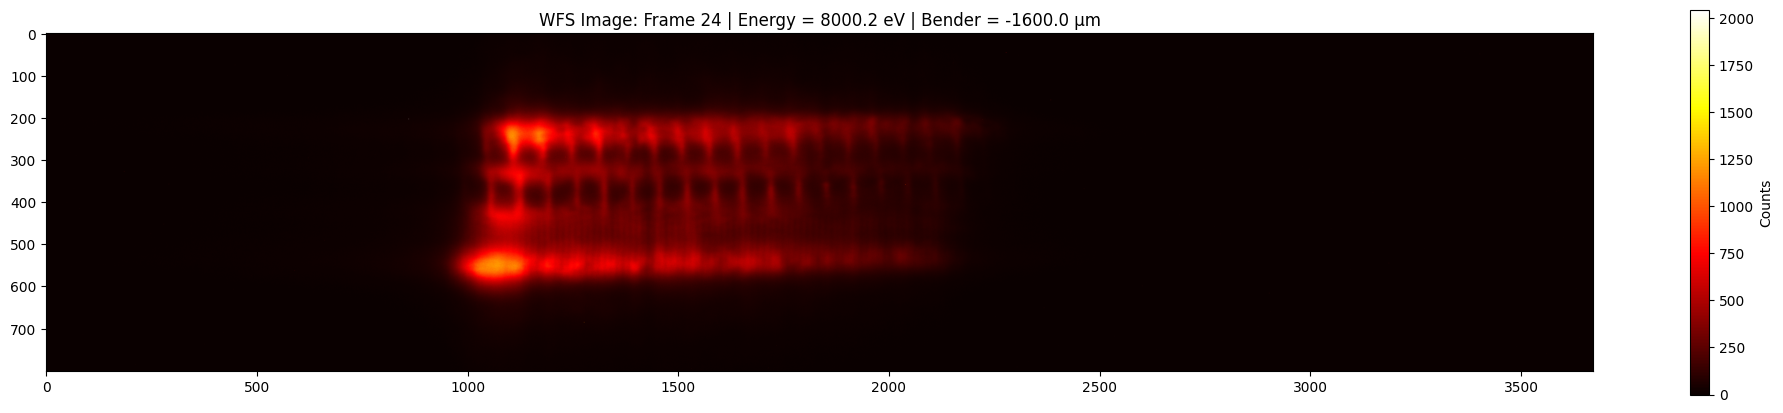

In [27]:
# Quick visualization of one image
idx = 24

plt.figure(figsize=(20, 8))
plt.imshow(images[idx].T, cmap='hot')
plt.title(f'WFS Image: Frame {idx} | Energy = {energy_eV[idx]:.1f} eV | Bender = {bender_um[idx]:.1f} µm')
plt.colorbar(label='Counts', shrink=0.5)
plt.tight_layout()
plt.show()

# ANALYSIS

## Single File 

Phase recon for image `idx=24`. 


In [ ]:
# --- Physical parameters ---
z_T             = 0.3                              # Grating-to-detector distance [m]
grating_pitch_m = 7e-6                             # Grating pitch from fabrication [m]
dx_m            = effective_pixel_size_um * 1e-6   # Effective pixel size [m]
wavelength_m    = 1.24e-6 / energy_eV[idx]         # X-ray wavelength [m]

print(f"z_T:             {z_T*1e3:.0f} mm")
print(f"Grating pitch:   {grating_pitch_m*1e6:.1f} µm")
print(f"Pixel size:      {dx_m*1e6:.3f} µm")
print(f"Wavelength:      {wavelength_m*1e9:.4f} nm  ({energy_eV[idx]:.1f} eV)")

z_T:             300 mm
Grating pitch:   7.0 µm
Pixel size:      0.480 µm
Wavelength:      0.1550 nm  (8000.2 eV)


### Data extraction


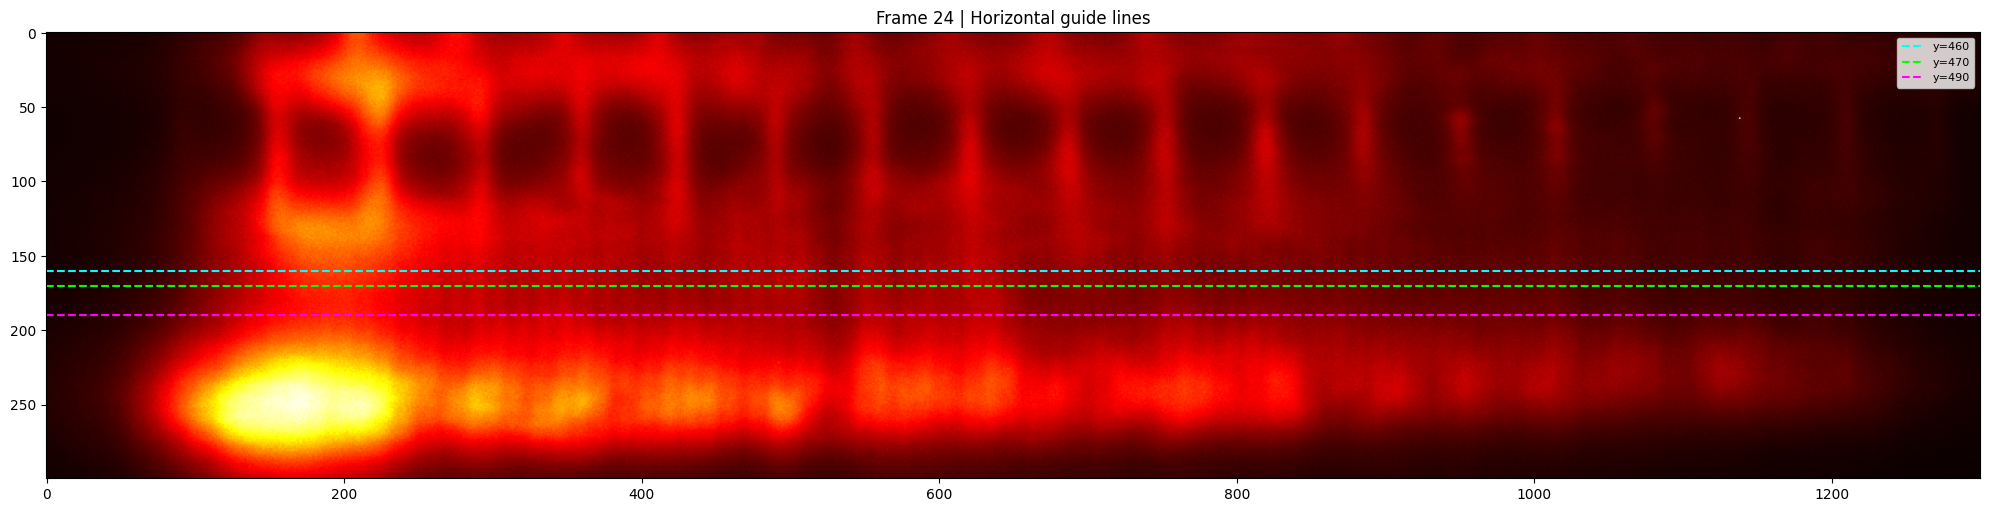

In [77]:
idx = 24
y_sub = 300   # pixels cropped from top for display

fig, ax = plt.subplots(figsize=(20, 5))
ax.imshow(images[idx].T[y_sub:600, 900:2200], cmap='hot')

for y, color in zip([460, 470, 490], ['cyan', 'lime', 'magenta']):
    ax.axhline(y - y_sub, color=color, linewidth=1.5, linestyle='--', label=f'y={y}')

ax.set_title(f'Frame {idx} | Horizontal guide lines')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

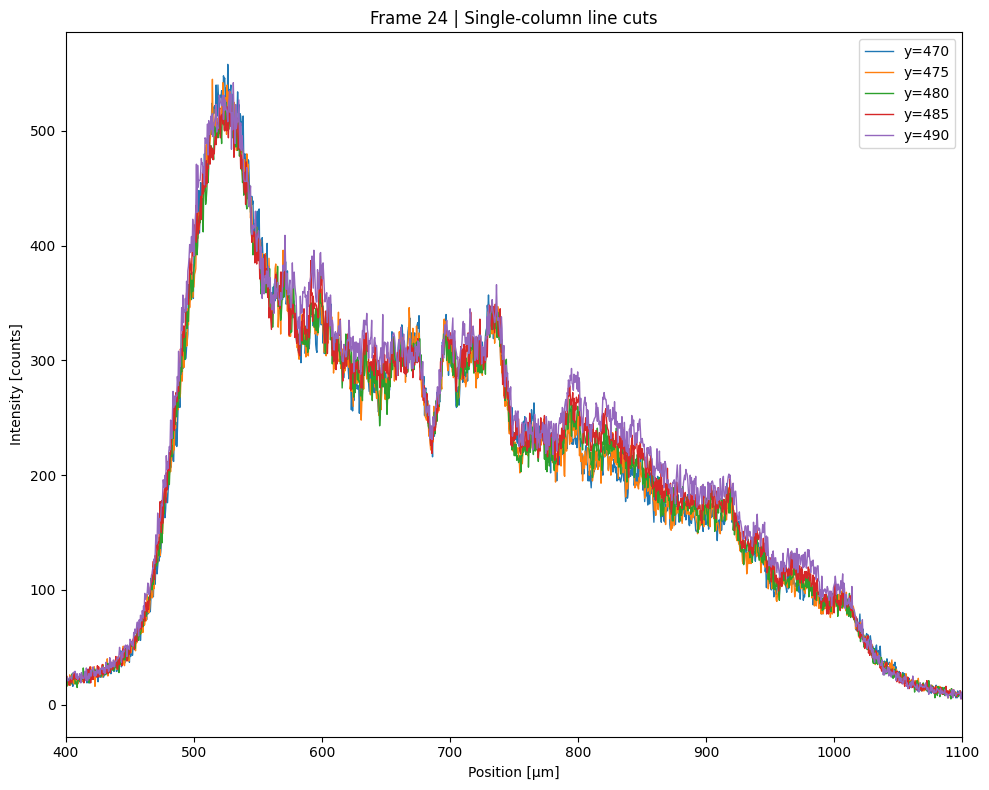

In [91]:
y_cuts = [470, 475, 480, 485, 490]#, 465, 495]

fig, ax = plt.subplots(figsize=(10, 8))
for y in y_cuts:
    profile = images[idx][:, y]
    x_m = np.arange(len(profile)) * dx_m
    if y in [465, 495]:
        ax.plot(x_m * 1e6, profile, linewidth=1, alpha = 0.5, linestyle='--', label=f'y={y}')
    else:
        ax.plot(x_m * 1e6, profile, linewidth=1, label=f'y={y}')

ax.set_xlabel('Position [µm]')
ax.set_ylabel('Intensity [counts]')
ax.set_xlim(400, 1100)
ax.legend(fontsize=10)
ax.set_title(f'Frame {idx} | Single-column line cuts')
plt.tight_layout()
plt.show()

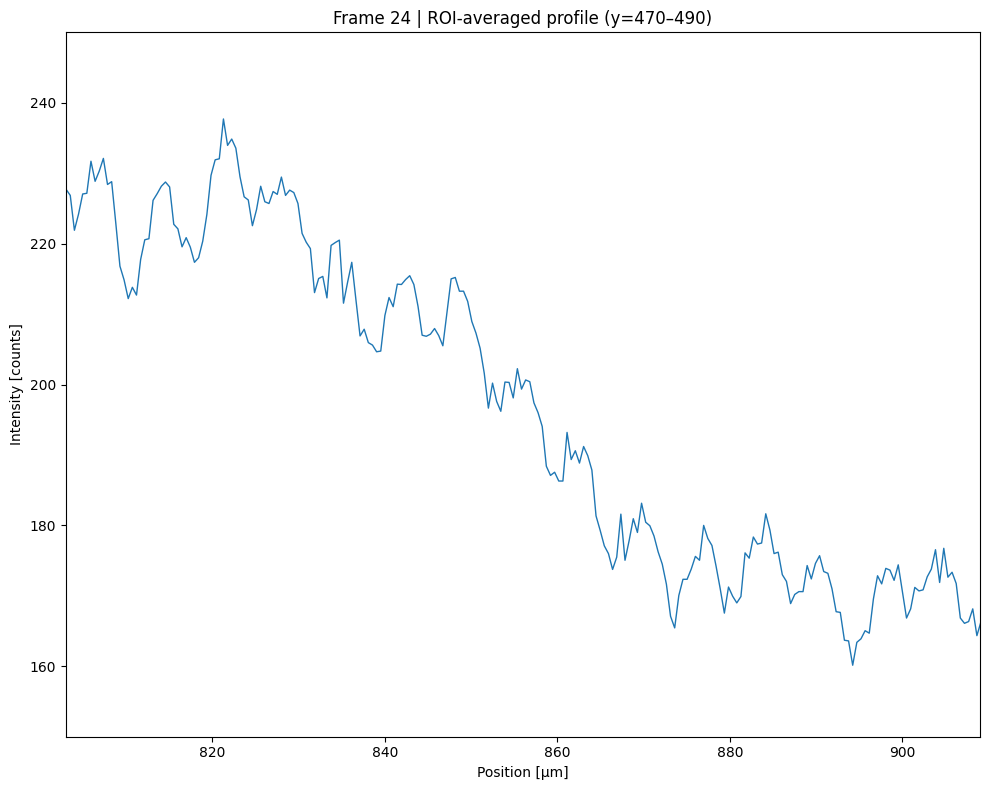

In [122]:
# Plot the 1D profile averaged over the fringe band (y=470–490)

# ROI definition 
x_roi = slice(None)          # full horizontal extent for now
y_roi = slice(470, 490)      # fringe band, confirmed from line cuts above
# y_roi = slice(475, 485)      # fringe band, confirmed from line cuts above --- IGNORE ---

roi = images[idx][:, y_roi]                  # shape: (n_x, 20)
line_profile = np.mean(roi, axis=1)          # average over y → 1D
x_m = np.arange(len(line_profile)) * dx_m

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(x_m * 1e6, line_profile, linewidth=1)
ax.set_xlabel('Position [µm]')
ax.set_ylabel('Intensity [counts]')
# ax.set_xlim(400, 1100)
ax.set_xlim(803, 909)
ax.set_ylim(150, 250)
ax.set_title(f'Frame {idx} | ROI-averaged profile (y=470–490)')
plt.tight_layout()
plt.show()

### Phase reconstruction


Ideal carrier:    142.86 cycles/mm  (1/p)
Measured carrier: 6.41 cycles/mm  (from FFT peak)
Ratio f_meas/f_ideal = 0.0449  (= 1/M = R1/(R1+zT))


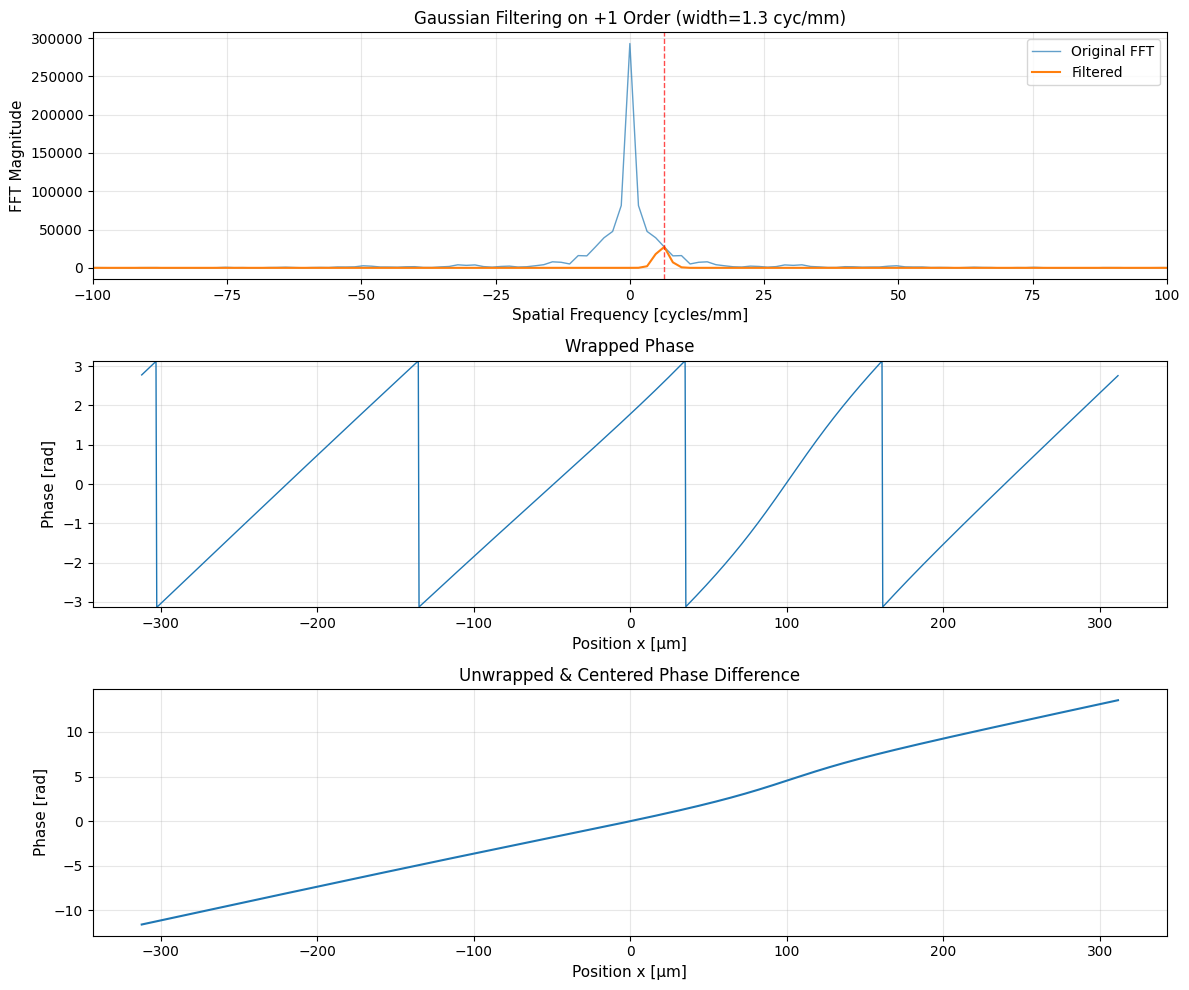

In [105]:
# Trim to beam region to reduce edge noise in FFT
x_beam = slice(900, 2200)   # pixel range covering ~450–1100 µm
line_beam = line_profile[x_beam]

# Phase extraction
phase_centered, x_coords, k_carrier, fig = wfu.calculate_phase_from_fringes(
    line_beam,
    pixel_size=dx_m,
    plot=True
)

# Carrier diagnostics
k_ideal = 1 / grating_pitch_m
print(f"Ideal carrier:    {k_ideal*1e-3:.2f} cycles/mm  (1/p)")
print(f"Measured carrier: {k_carrier*1e-3:.2f} cycles/mm  (from FFT peak)")
print(f"Ratio f_meas/f_ideal = {k_carrier/k_ideal:.4f}  (= 1/M = R1/(R1+zT))")

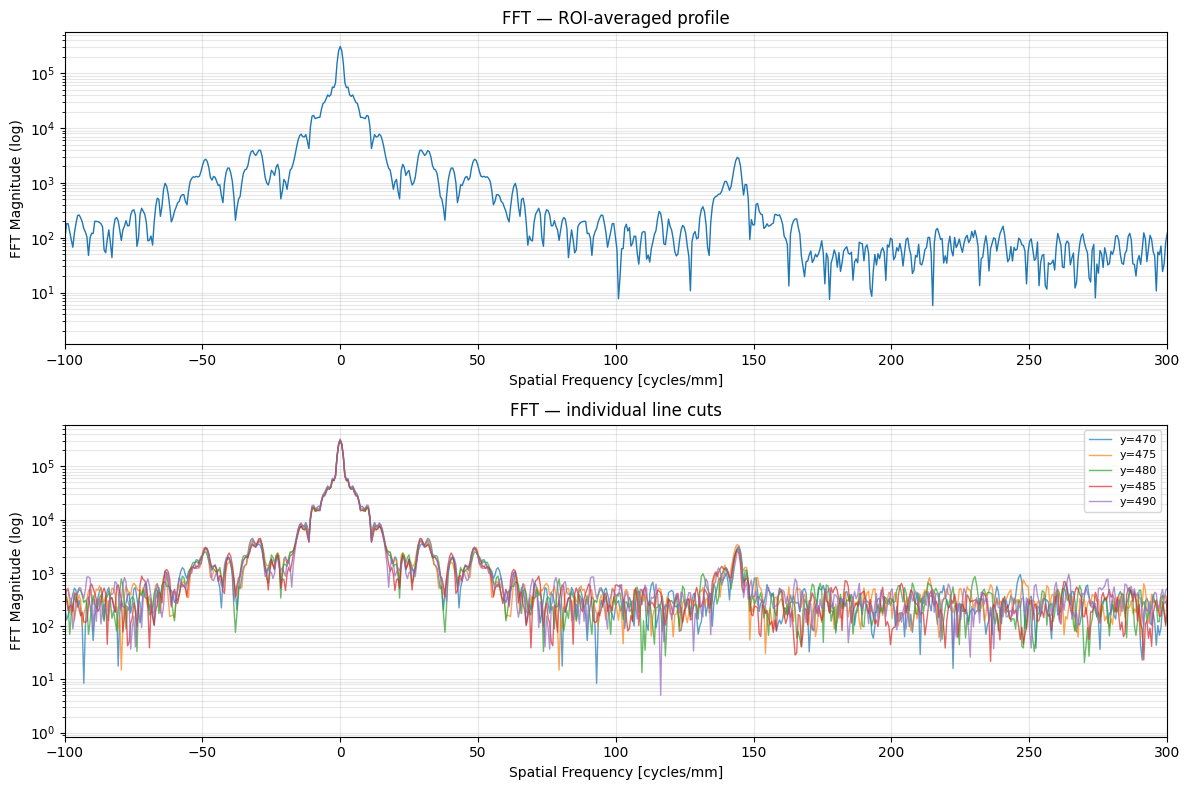

In [151]:
# Trim to beam region to reduce edge noise in FFT
# x_beam = slice(900, 2200)   # pixel range covering ~450–1100 µm
x_beam = slice(0, len(line_profile))   # full range 

# For individual line cuts (same x range)
y_cuts = [470, 475, 480, 485, 490]
profiles = {y: images[idx][x_beam, y] for y in y_cuts}
line_beam = line_profile[x_beam]

# FFT
fft_avg = np.fft.fftshift(np.fft.fft(line_beam))
freq    = np.fft.fftshift(np.fft.fftfreq(len(line_beam), dx_m))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax = axes[0]
ax.semilogy(freq * 1e-3, np.abs(fft_avg), linewidth=1)
ax.set_xlabel('Spatial Frequency [cycles/mm]')
ax.set_ylabel('FFT Magnitude (log)')
ax.set_title('FFT — ROI-averaged profile')
ax.set_xlim(-100, 300)
ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
for y, prof in profiles.items():
    fft_y = np.fft.fftshift(np.fft.fft(prof))
    ax.semilogy(freq * 1e-3, np.abs(fft_y), linewidth=1, alpha=0.7, label=f'y={y}')
ax.set_xlabel('Spatial Frequency [cycles/mm]')
ax.set_ylabel('FFT Magnitude (log)')
ax.set_title('FFT — individual line cuts')
ax.set_xlim(-100, 300)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Measured carrier: 144.11 cycles/mm
Ideal carrier:    142.86 cycles/mm
Ratio:            1.0088


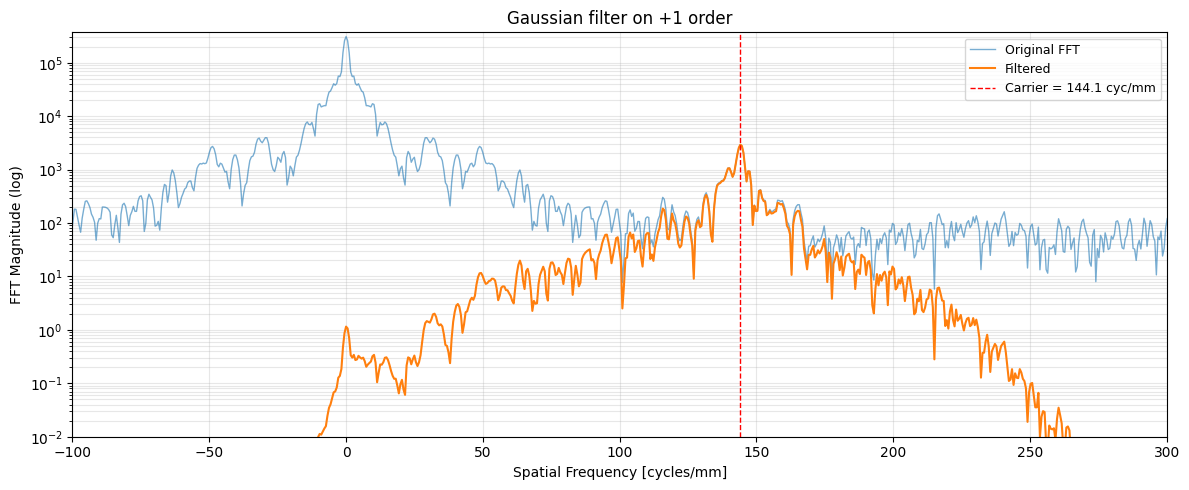

In [152]:
# --- Carrier detection ---
search_mask = (freq >= 100e3) & (freq <= 200e3)
carrier_idx  = np.argmax(np.abs(fft_avg) * search_mask)
k_carrier    = freq[carrier_idx]

print(f"Measured carrier: {k_carrier*1e-3:.2f} cycles/mm")
print(f"Ideal carrier:    {1/grating_pitch_m*1e-3:.2f} cycles/mm")
print(f"Ratio:            {k_carrier/(1/grating_pitch_m):.4f}")

# --- Gaussian filter centered on +1 order ---
filter_sigma  = k_carrier / 5.0   # filter width ~ carrier/5
gauss_filter  = np.exp(-0.5 * ((freq - k_carrier) / filter_sigma)**2)
fft_filtered  = fft_avg * gauss_filter

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(freq * 1e-3, np.abs(fft_avg),      linewidth=1,   alpha=0.6, label='Original FFT')
ax.semilogy(freq * 1e-3, np.abs(fft_filtered),  linewidth=1.5, label='Filtered')
ax.axvline(k_carrier * 1e-3, color='red', linestyle='--', linewidth=1, label=f'Carrier = {k_carrier*1e-3:.1f} cyc/mm')
ax.set_xlabel('Spatial Frequency [cycles/mm]')
ax.set_ylabel('FFT Magnitude (log)')
ax.set_title('Gaussian filter on +1 order')
ax.set_xlim(-100, 300)
ax.set_ylim(1e-2, np.abs(fft_avg).max()*1.2)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

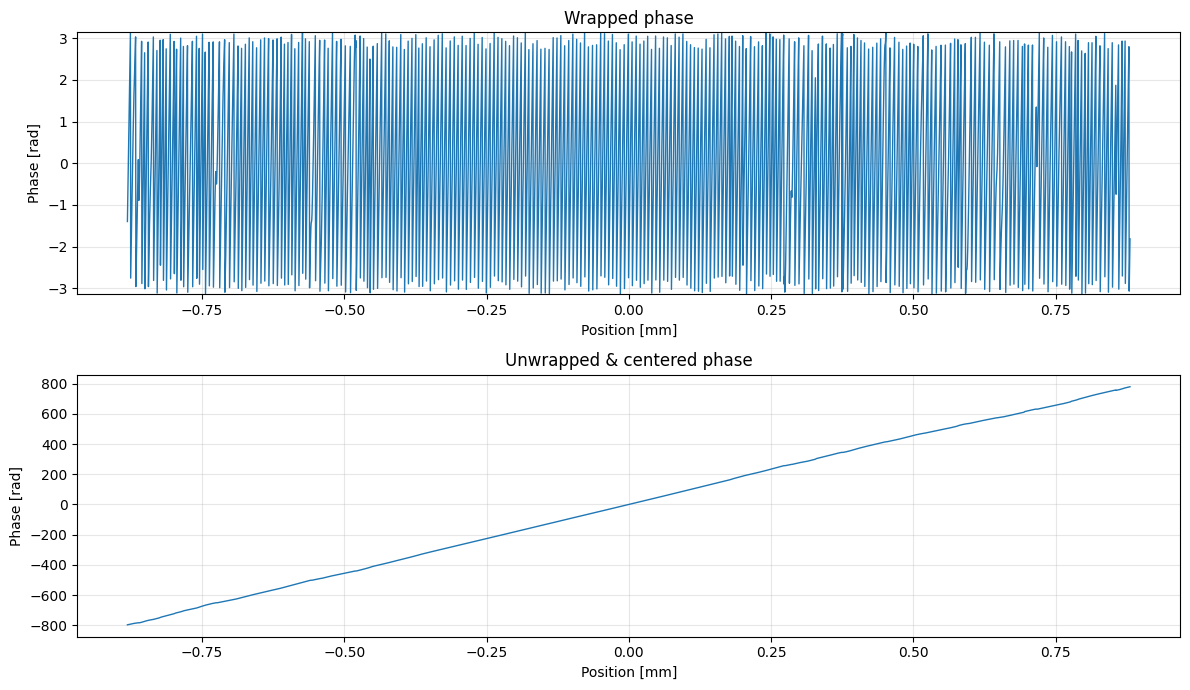

In [153]:
# IFFT of filtered spectrum → complex field
complex_field   = np.fft.ifft(np.fft.ifftshift(fft_filtered))

# Wrapped phase
phase_wrapped   = np.angle(complex_field)

# Unwrap and center at midpoint
phase_unwrapped = np.unwrap(phase_wrapped)
phase_centered  = phase_unwrapped - phase_unwrapped[len(phase_unwrapped)//2]

# Spatial coordinates
x_m = np.arange(len(line_beam)) * dx_m
x_m = x_m - x_m[len(x_m)//2]   # center at 0

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

ax = axes[0]
ax.plot(x_m * 1e3, phase_wrapped, linewidth=1)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Phase [rad]')
ax.set_title('Wrapped phase')
ax.set_ylim(-np.pi, np.pi)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_m * 1e3, phase_centered, linewidth=1)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Phase [rad]')
ax.set_title('Unwrapped & centered phase')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

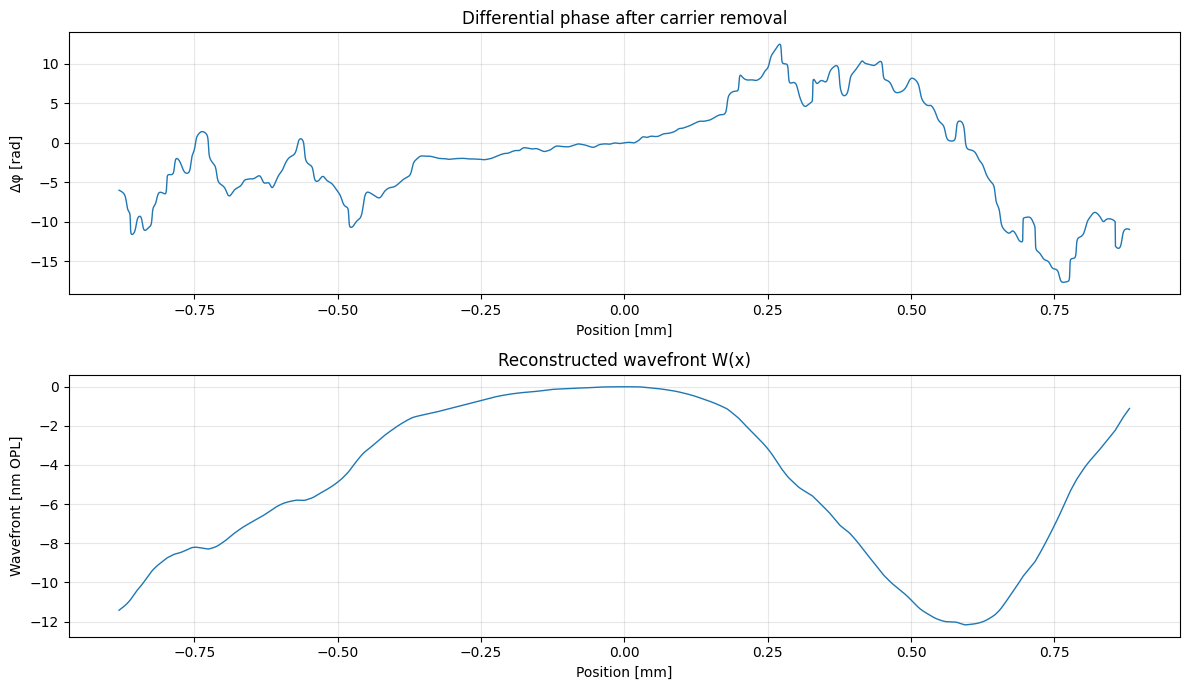

Wavefront PV:  12.17 nm
Wavefront RMS: 4.02 nm


In [154]:
# --- Carrier removal (ideal pitch) ---
carrier_ramp    = 2 * np.pi / grating_pitch_m * x_m
carrier_ramp    = carrier_ramp - carrier_ramp[len(carrier_ramp)//2]
delta_phi       = phase_centered - carrier_ramp

# --- Integration ---
W_temp          = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
wavefront_rad   = W_temp - W_temp[len(W_temp)//2]
wavefront_nm    = wavefront_rad * wavelength_m / (2 * np.pi) * 1e9

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

ax = axes[0]
ax.plot(x_m * 1e3, delta_phi, linewidth=1)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Δφ [rad]')
ax.set_title('Differential phase after carrier removal')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_m * 1e3, wavefront_nm, linewidth=1)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Wavefront [nm OPL]')
ax.set_title('Reconstructed wavefront W(x)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Wavefront PV:  {wavefront_nm.max() - wavefront_nm.min():.2f} nm")
print(f"Wavefront RMS: {np.std(wavefront_nm):.2f} nm")

## Multi-Energy

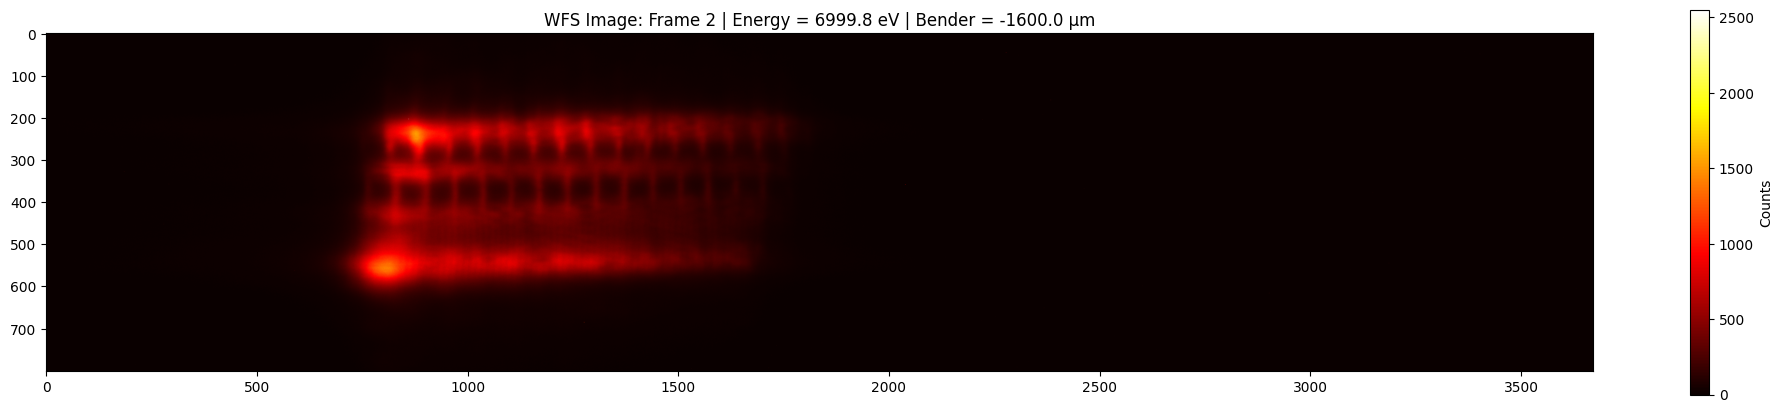

In [169]:
# Quick visualization of one image
idx = 24 + 11*(-2)

plt.figure(figsize=(20, 8))
plt.imshow(images[idx].T, cmap='hot')
plt.title(f'WFS Image: Frame {idx} | Energy = {energy_eV[idx]:.1f} eV | Bender = {bender_um[idx]:.1f} µm')
plt.colorbar(label='Counts', shrink=0.5)
plt.tight_layout()
plt.show()

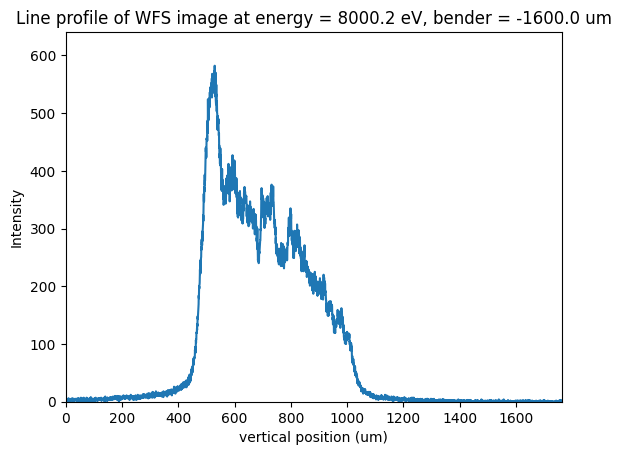

In [48]:
x_m = (np.arange(images[idx].shape[0])) * effective_pixel_size_um *1e-6
line_profile = images[idx][:,495]
plt.plot(x_m*1e6, line_profile)
plt.xlabel('vertical position (um)')
plt.ylabel('Intensity')
plt.title('Line profile of WFS image at energy = {:1.1f} eV, bender = {:1.1f} um'.format(energy_eV[idx], bender_um[idx]))
plt.xlim(0, x_m[-1]*1e6)
plt.ylim(0, line_profile.max()*1.1)
plt.show()


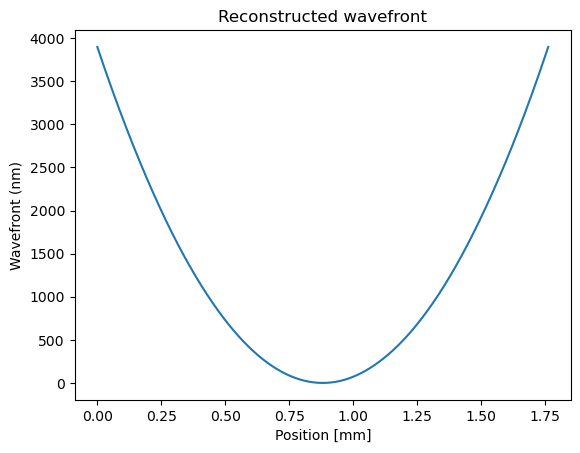

In [70]:
#other useful metadata:
grating_pitch_m = 7e-6  # 
chip_ccd_distance = 300e-3


grating_freq_cpm = 1/grating_pitch_m  # cycles per micron for 7 um pitch
wavelength_m = 1.24e-6 / (energy_eV[idx])  # Convert eV to wavelength in meters
px_m = effective_pixel_size_um * 1e-6  # Convert effective pixel size to meters

line = line_profile
line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))
I_fft = line_FFT

# Create frequency array
freq = freq_y_cpm
M = len(freq)
df = freq[1]-freq[0]  # Frequency resolution [1/m]

mask = (freq > 0.12e6) & (freq < 0.17e6)

# Find peaks in FFT spectrum (use magnitude)
I_fft_magnitude = np.abs(I_fft)
# peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

# Identify carrier frequency (should be at ±1/pitch)
carrier_freq_ideal = grating_freq_cpm
#carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
carrier_idx = np.argmax(I_fft_magnitude*mask)
carrier_freq_measured = freq[carrier_idx]


# Create Gaussian filter centered on +1 order
filter_width = 10.0  # pixels (standard deviation)
x_indices = np.arange(M)
gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

# Apply filter to FFT
I_fft_filtered = I_fft * gaussian_filter

# Normalize for visualization (so all curves are visible on same plot)
I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

# Inverse FFT to get complex field
complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

# Extract amplitude and wrapped phase
amplitude = np.abs(complex_field)
phase_wrapped = np.angle(complex_field)

# Standard unwrap (left-to-right) and center at x=0
phase_unwrapped = np.unwrap(phase_wrapped)
phase_centered = phase_unwrapped - phase_unwrapped[M//2]

dy_m = x_m[1] - x_m[0]  # Spatial sampling interval [m]

# Simple cumulative integration with scaling
wavefront_m = np.cumsum(phase_centered) * dy_m / grating_pitch_m * wavelength_m / 2

# Re-center at x=0 to remove piston term
wavefront_reconstructed = wavefront_m - wavefront_m[M//2]
wavefront_wave = wavefront_reconstructed # Convert to meters


plt.plot(x_m*1e3, wavefront_reconstructed*1e9)
plt.title('Reconstructed wavefront')
plt.xlabel('Position [mm]')
plt.ylabel('Wavefront (nm)')
plt.show()

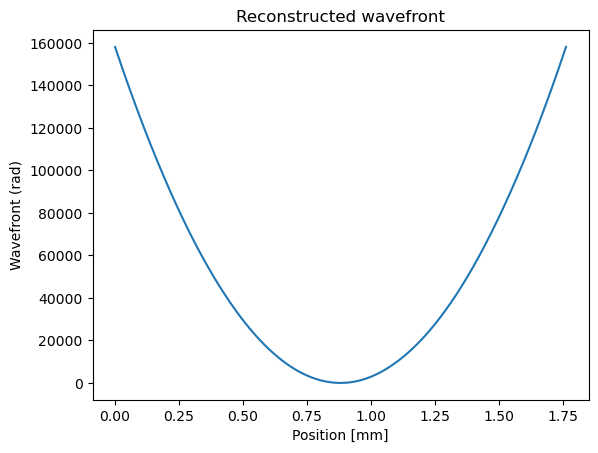

In [71]:
# Simple cumulative integration with scaling
wavefront_m = np.cumsum(phase_centered) * dy_m / grating_pitch_m * wavelength_m / 2

# Re-center at x=0 to remove piston term
wavefront_reconstructed = wavefront_m - wavefront_m[M//2]
wavefront_rad = wavefront_reconstructed/wavelength_m * 2 * np.pi # Convert to radians


plt.plot(x_m*1e3, wavefront_rad)
plt.title('Reconstructed wavefront')
plt.xlabel('Position [mm]')
plt.ylabel('Wavefront (rad)')
plt.show()

In [75]:
def estimate_wavefront(line_profile):
    #other useful metadata:
    grating_pitch_m = 7e-6  # 
    chip_ccd_distance = 300e-3


    grating_freq_cpm = 1/grating_pitch_m  # cycles per micron for 7 um pitch
    wavelength_m = 1.24e-6 / (energy_eV[idx])  # Convert eV to wavelength in meters
    px_m = effective_pixel_size_um * 1e-6  # Convert effective pixel size to meters

    line = line_profile
    line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
    freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))
    I_fft = line_FFT

    # Create frequency array
    freq = freq_y_cpm
    M = len(freq)
    df = freq[1]-freq[0]  # Frequency resolution [1/m]

    mask = (freq > 0.12e6) & (freq < 0.17e6)

    # Find peaks in FFT spectrum (use magnitude)
    I_fft_magnitude = np.abs(I_fft)
    # peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

    # Identify carrier frequency (should be at ±1/pitch)
    carrier_freq_ideal = grating_freq_cpm
    #carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
    carrier_idx = np.argmax(I_fft_magnitude*mask)
    carrier_freq_measured = freq[carrier_idx]


    # Create Gaussian filter centered on +1 order
    filter_width = 10.0  # pixels (standard deviation)
    x_indices = np.arange(M)
    gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

    # Apply filter to FFT
    I_fft_filtered = I_fft * gaussian_filter

    # Normalize for visualization (so all curves are visible on same plot)
    I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
    I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

    # Inverse FFT to get complex field
    complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

    # Extract amplitude and wrapped phase
    amplitude = np.abs(complex_field)
    phase_wrapped = np.angle(complex_field)

    # Standard unwrap (left-to-right) and center at x=0
    phase_unwrapped = np.unwrap(phase_wrapped)
    phase_centered = phase_unwrapped - phase_unwrapped[M//2]

    dy_m = x_m[1] - x_m[0]  # Spatial sampling interval [m]

    # Simple cumulative integration with scaling
    wavefront_m = np.cumsum(phase_centered) * dy_m / grating_pitch_m * wavelength_m / 2

    # Re-center at x=0 to remove piston term
    wavefront_reconstructed = wavefront_m - wavefront_m[M//2]
    wavefront_wave = wavefront_reconstructed # Convert to meters

    return wavefront_wave



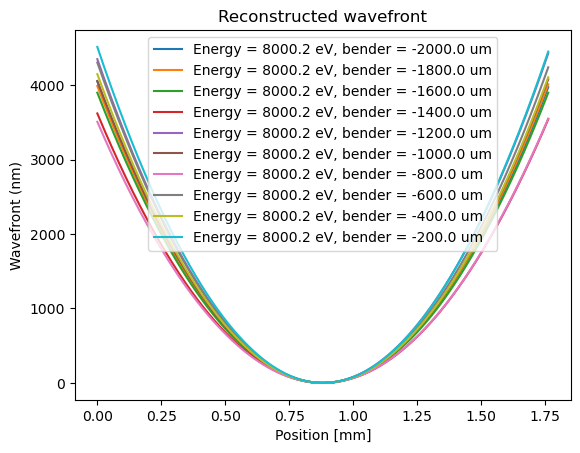

In [76]:
for idx in range(22,32):
    line_profile = images[idx][:,495]
    wavefront = estimate_wavefront(line_profile)
    plt.plot(x_m*1e3, wavefront*1e9, label='Energy = {:1.1f} eV, bender = {:1.1f} um'.format(energy_eV[idx], bender_um[idx]))
plt.title('Reconstructed wavefront')
plt.xlabel('Position [mm]')
plt.ylabel('Wavefront (nm)')
plt.legend()
plt.show()

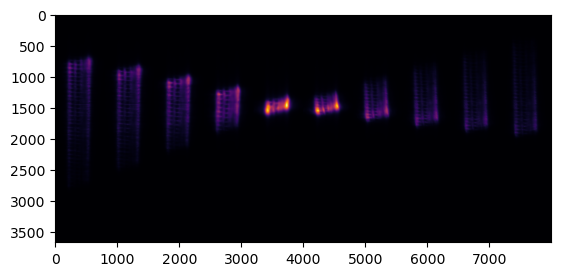

In [79]:
img_list = []
for index in range(22,32):
    img_list.append(images[index])

# Stack the images horizontally
stacked_image = np.hstack(img_list)
plt.imshow(stacked_image, cmap='inferno')
plt.show()

